In [2]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import zscore

In [3]:
raw_data = pd.read_csv("../data/raw/diabetic_data.csv", keep_default_na=False, na_values=["?"], low_memory=False)

# 1. Inspect Missing Values

In [5]:
missing_value_percentage = (raw_data.isna().sum() / len(raw_data)) * 100

missing_value_df = pd.DataFrame({
    'Column': missing_value_percentage.index,
    'Missing Value Percentage': missing_value_percentage.values
})

missing_value_df = missing_value_df.sort_values(by='Missing Value Percentage', ascending=False)

missing_value_df

,Column,Missing Value Percentage
5,weight,96.858479
11,medical_specialty,49.082208
10,payer_code,39.557416
2,race,2.233555
20,diag_3,1.398306
19,diag_2,0.351787
18,diag_1,0.020636
0,encounter_id,0.000000
38,tolazamide,0.000000
31,glyburide,0.000000


There seems to be a lot of missing values with **3** main features, these features being `weight`, `medical_specialty`, and `payer_code`. These features need to be dropped because they exceed the **20%** acceptable threshold for missing values.

# 2. Check Duplicates and Inconsistencies

In [6]:
duplicate_rows = raw_data[raw_data.duplicated()]

duplicate_rows

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


There are no duplicate rows. That is good to know.

In [7]:
unique_summary = []

for col in raw_data:
    unique_vals = raw_data[col].unique()
    unique_count = len(unique_vals)
    unique_summary.append({
        'Column': col,
        'Number of Unique Values': unique_count,
        'First Few Unique Values': unique_vals[:5] if unique_count > 5 else unique_vals
    })

unique_summary_df = pd.DataFrame(unique_summary)
unique_summary_df

,Column,Number of Unique Values,First Few Unique Values
0,encounter_id,101766,"[2278392, 149190, 64410, 500364, 16680]"
1,patient_nbr,71518,"[8222157, 55629189, 86047875, 82442376, 42519267]"
2,race,6,"[Caucasian, AfricanAmerican, nan, Other, Asian]"
3,gender,3,"[Female, Male, Unknown/Invalid]"
4,age,10,"[[0-10), [10-20), [20-30), [30-40), [40-50)]"
5,weight,10,"[nan, [75-100), [50-75), [0-25), [100-125)]"
6,admission_type_id,8,"[6, 1, 2, 3, 4]"
7,discharge_disposition_id,26,"[25, 1, 3, 6, 2]"
8,admission_source_id,17,"[1, 7, 2, 4, 5]"
9,time_in_hospital,14,"[1, 3, 2, 4, 5]"


At first glance, the values across the features appear to be consistent with no obvious discrepancies. Therefore, it will be assumed that the dataset is consistent.

# 3. Examine data types and ranges

In [8]:
raw_data.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [9]:
raw_data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [10]:
min_max_summary = []

numerical_cols = raw_data.select_dtypes(include="number")

for col in numerical_cols:
    col_min = numerical_cols[col].min()
    col_max = numerical_cols[col].max()
    min_max_summary.append({
        'Column': col,
        'Minimum': col_min,
        'Maximum': col_max
    })

min_max_summary_df = pd.DataFrame(min_max_summary)
min_max_summary_df

,Column,Minimum,Maximum
0,encounter_id,12522,443867222
1,patient_nbr,135,189502619
2,admission_type_id,1,8
3,discharge_disposition_id,1,28
4,admission_source_id,1,25
5,time_in_hospital,1,14
6,num_lab_procedures,1,132
7,num_procedures,0,6
8,num_medications,1,81
9,number_outpatient,0,42


# 4. Univariate analysis

### Numerical Features

In [11]:
raw_data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


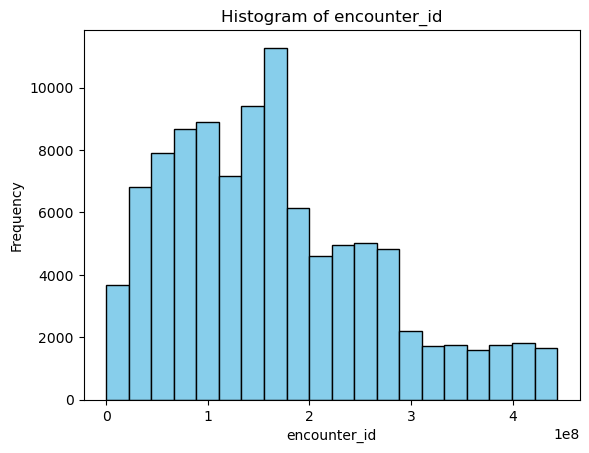

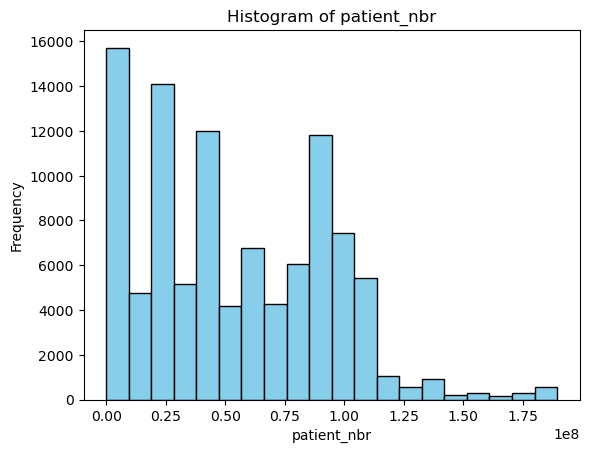

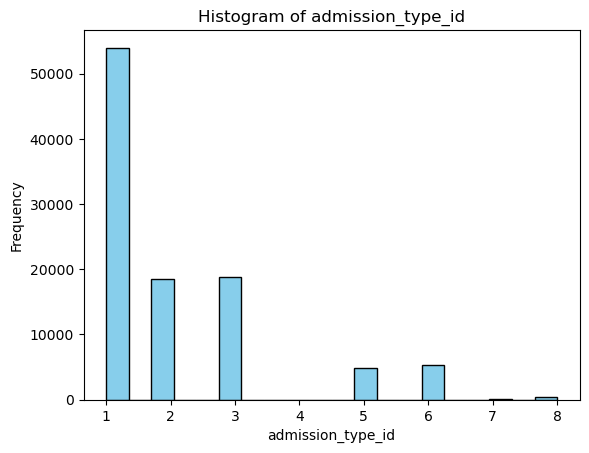

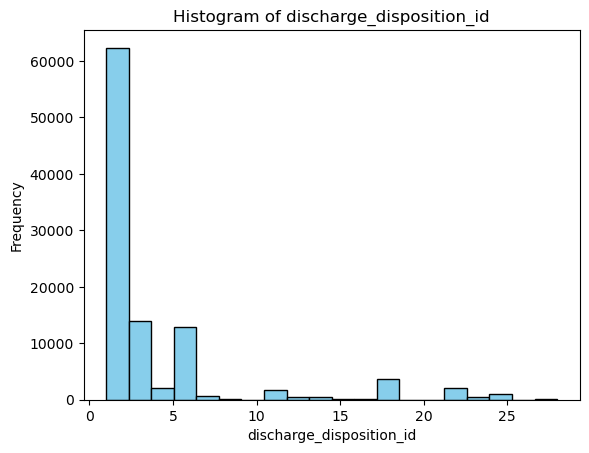

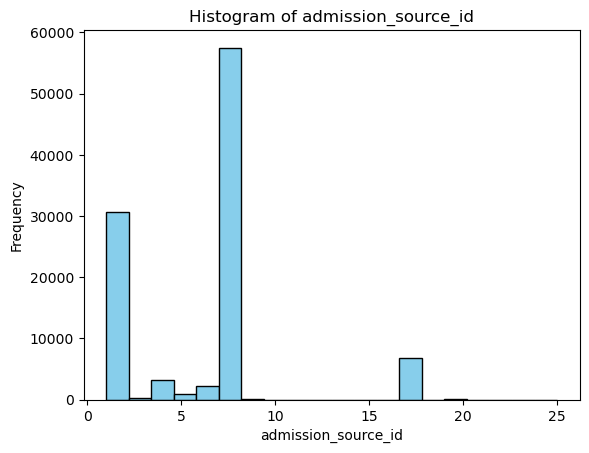

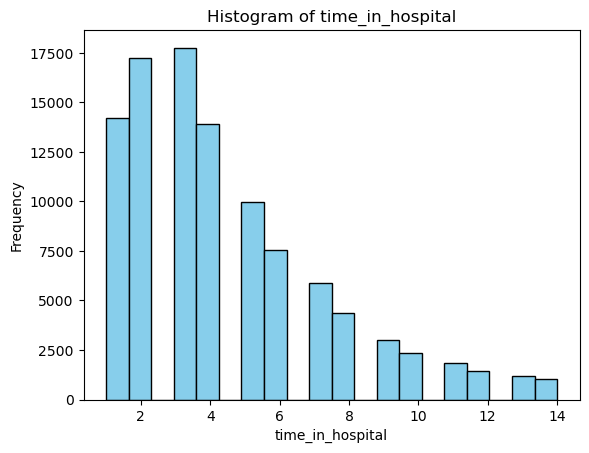

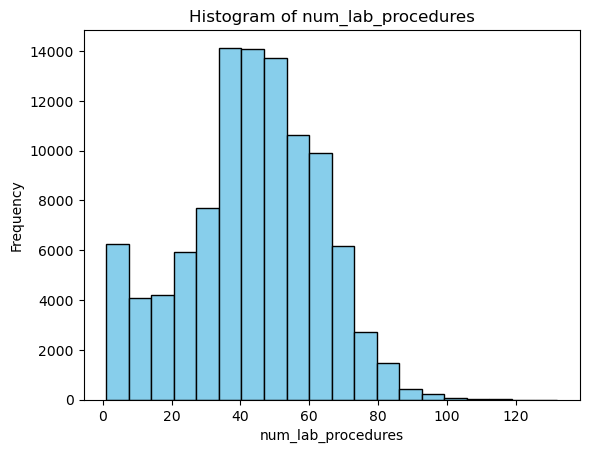

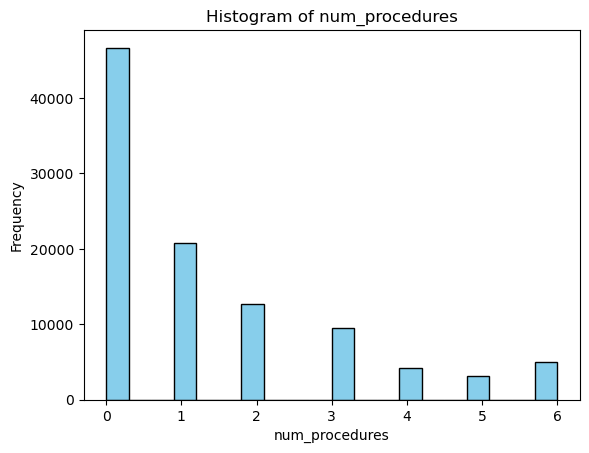

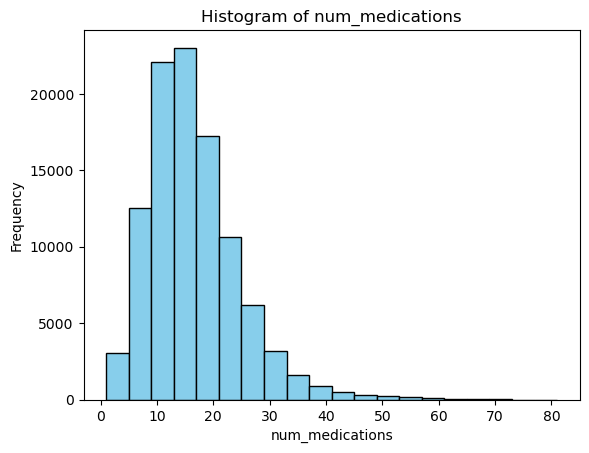

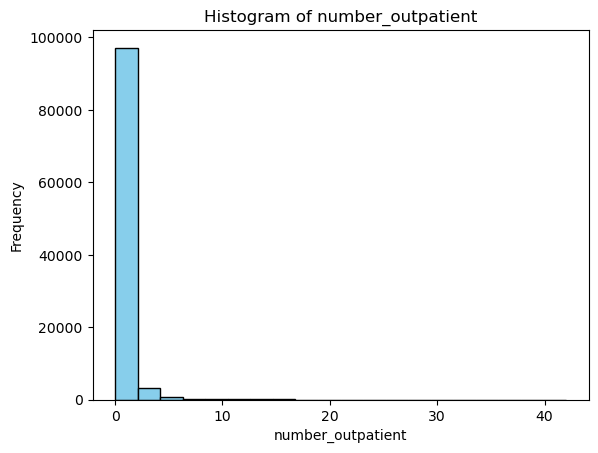

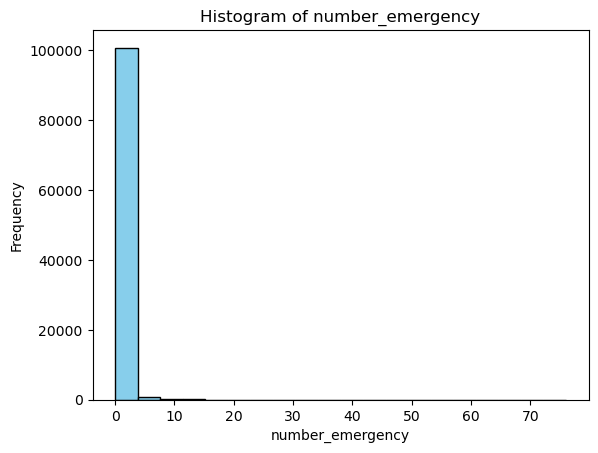

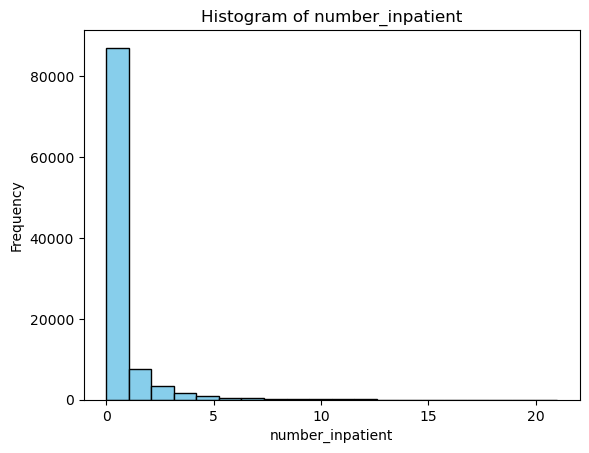

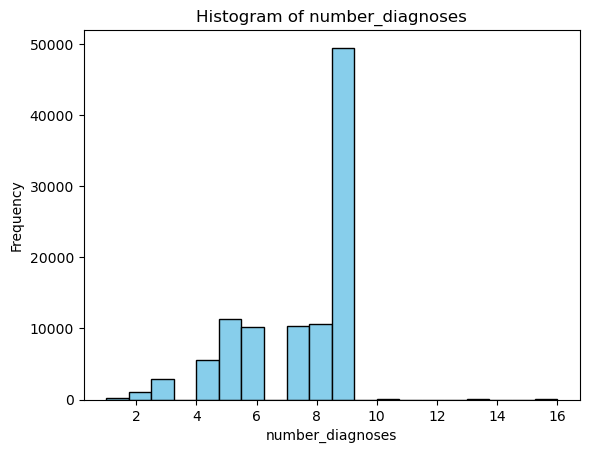

In [12]:
for col in numerical_cols:
    plt.hist(raw_data[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.ylabel('Frequency')
    plt.xlabel(col)
    plt.show()

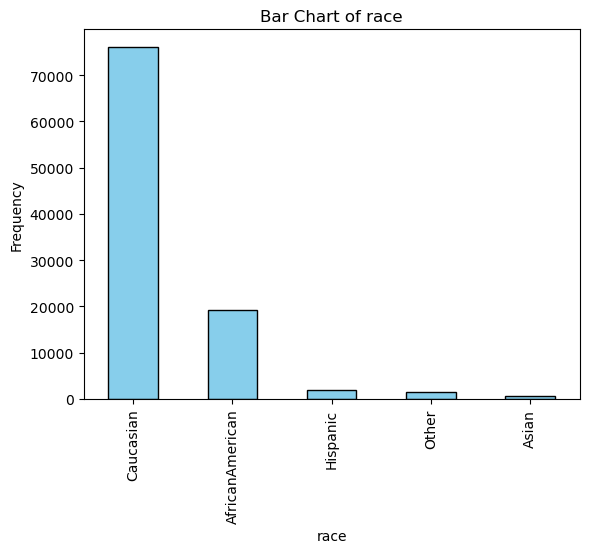

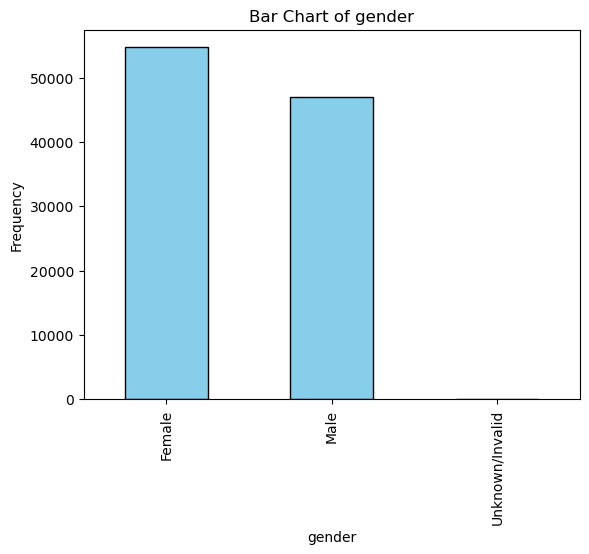

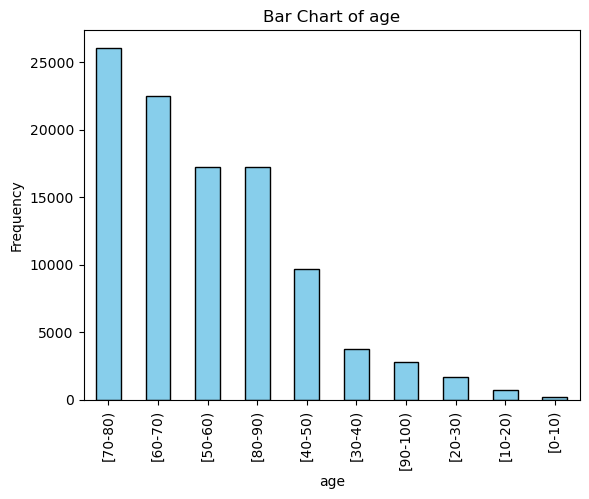

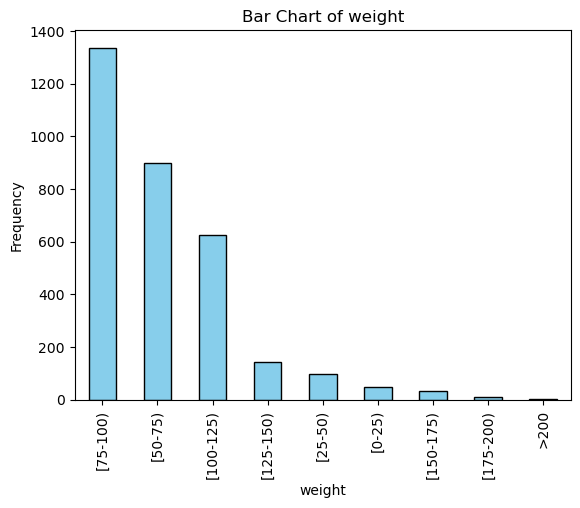

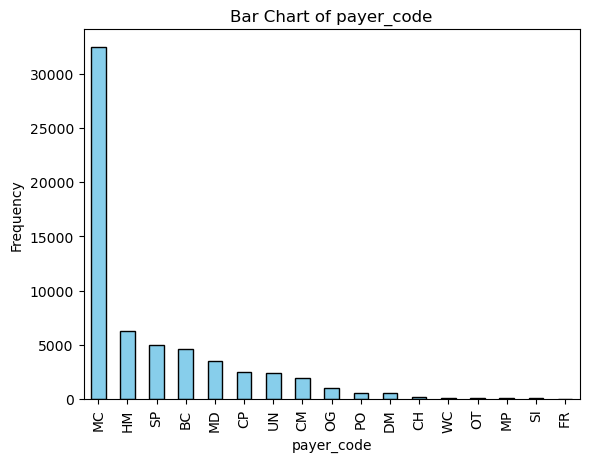

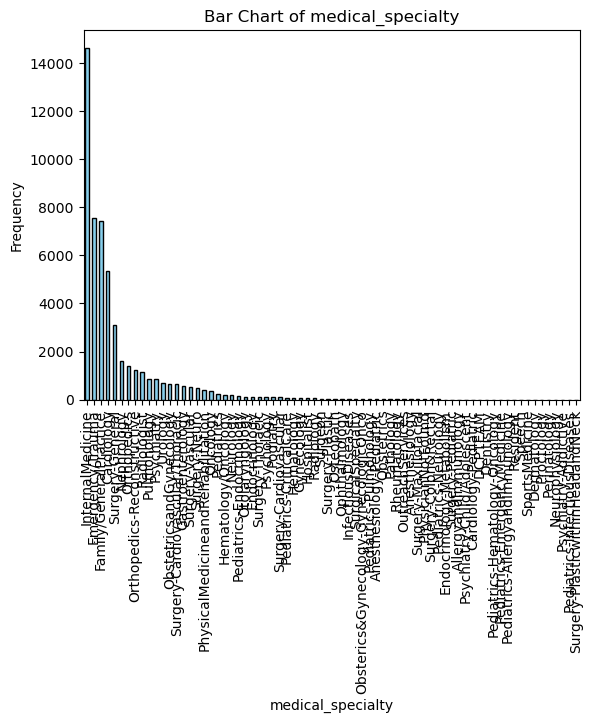

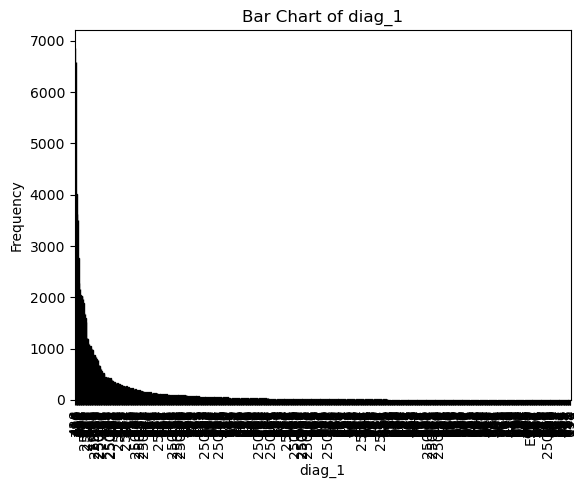

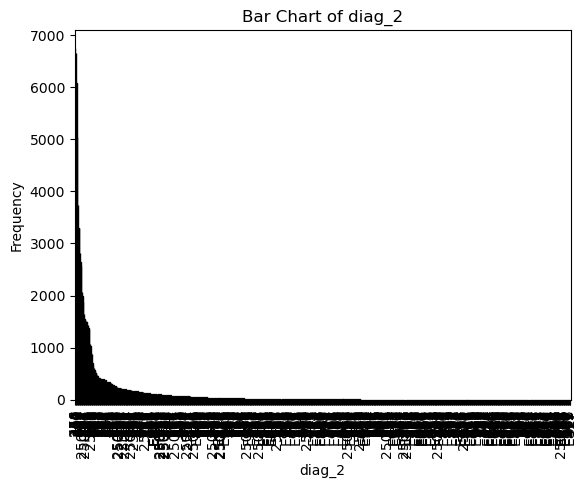

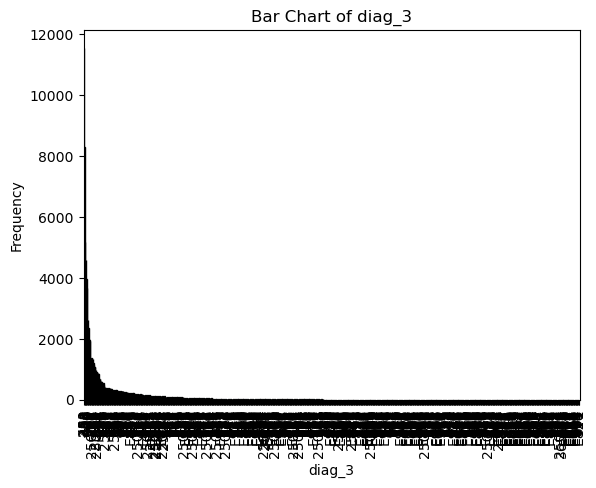

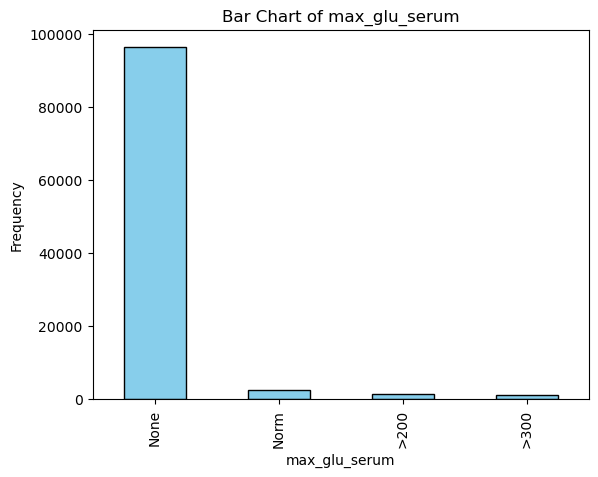

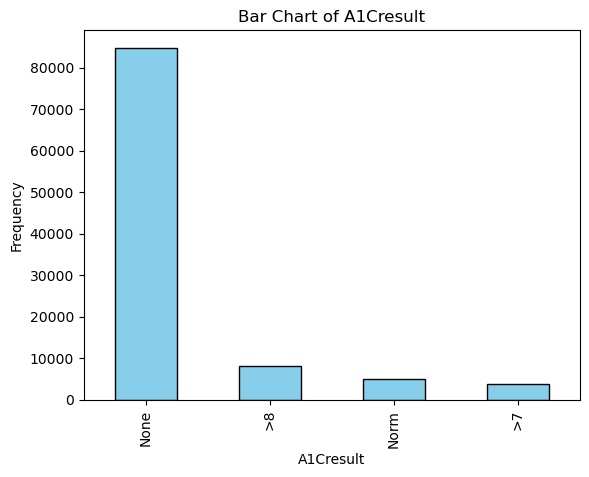

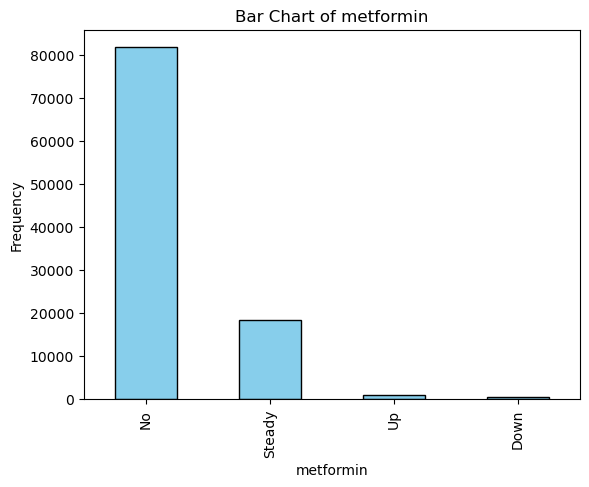

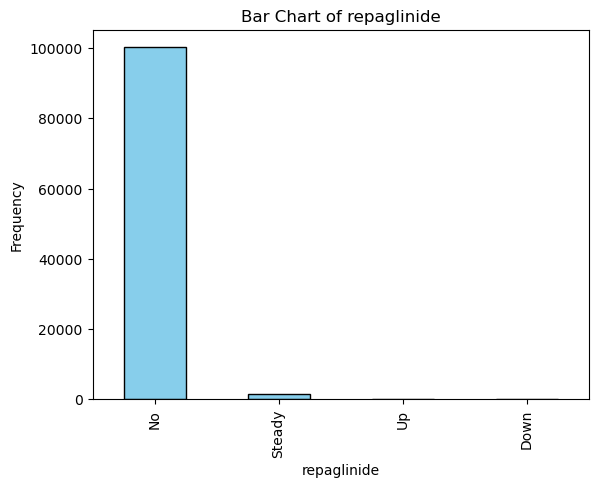

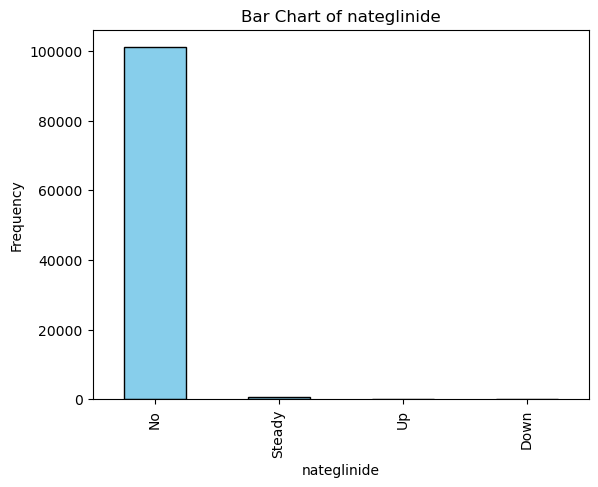

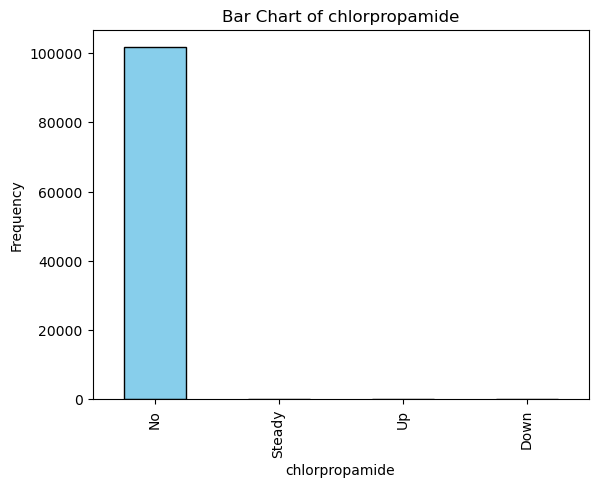

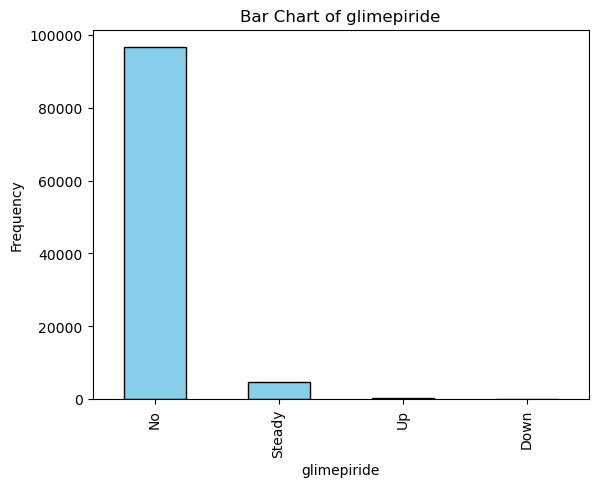

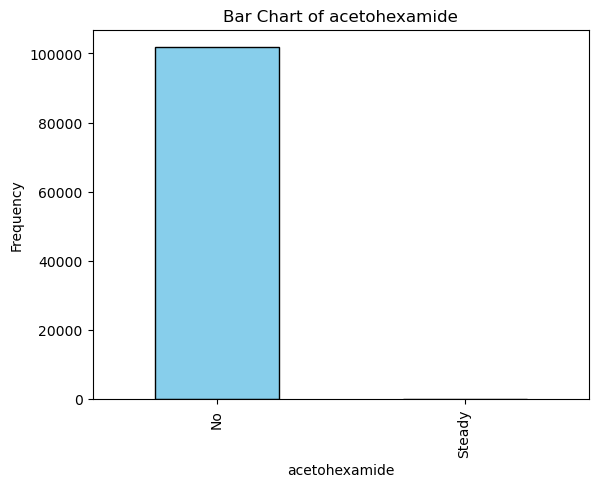

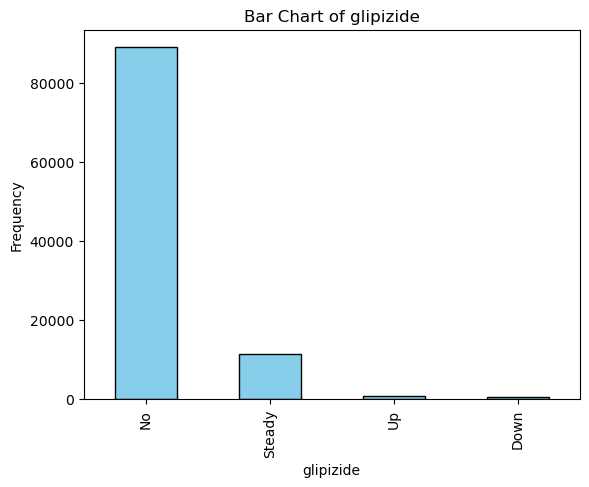

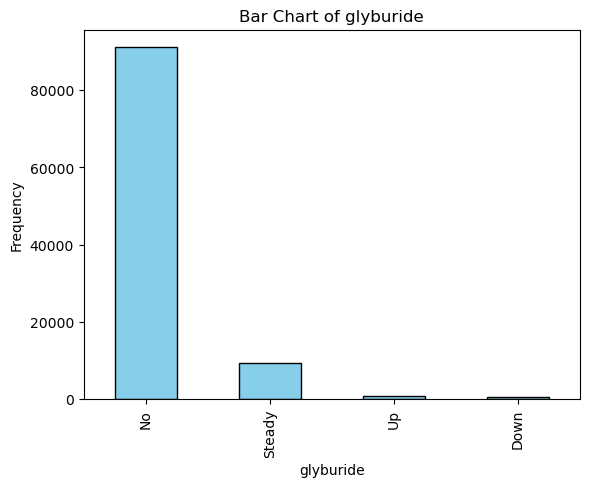

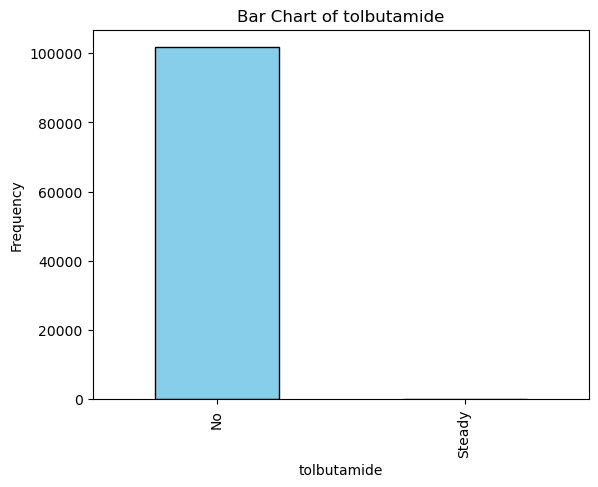

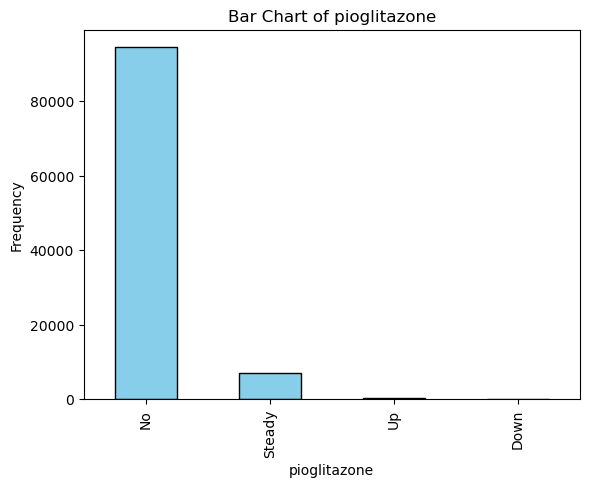

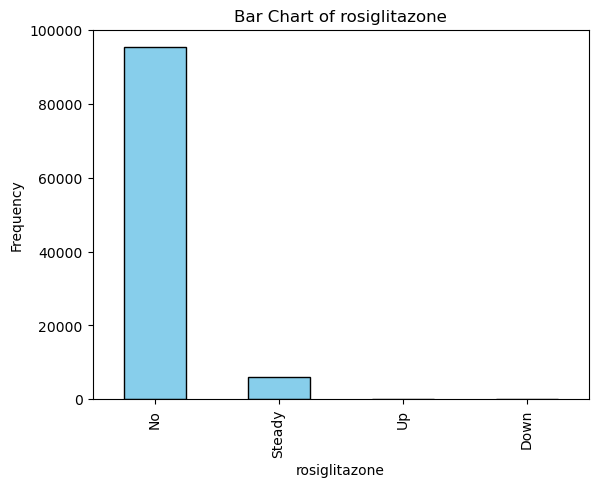

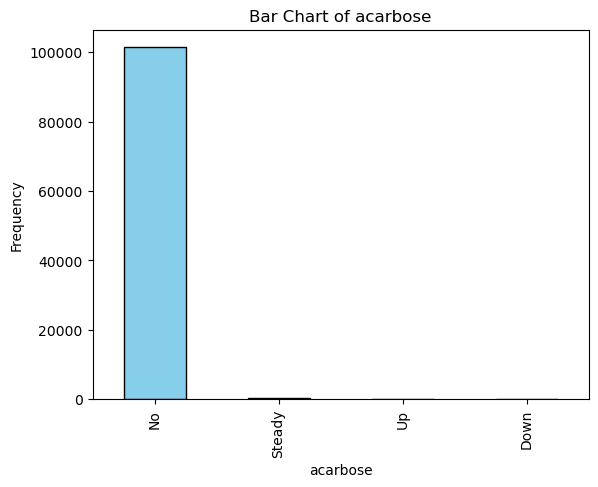

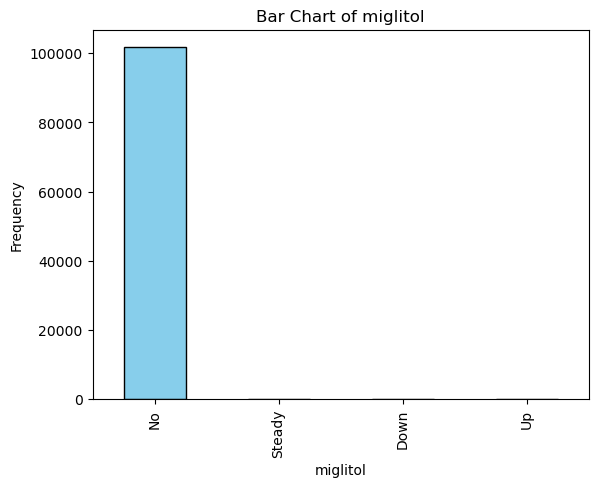

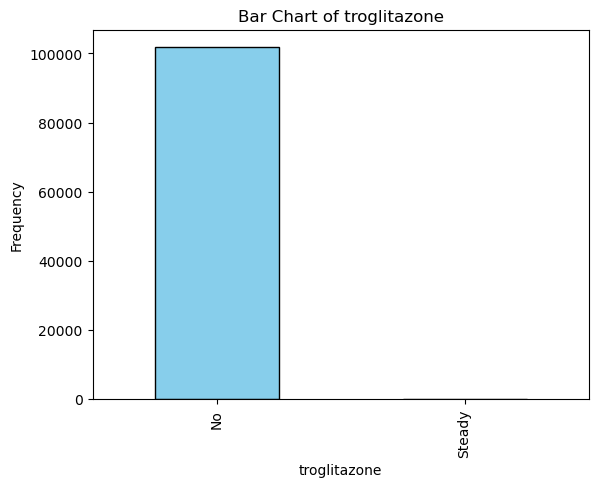

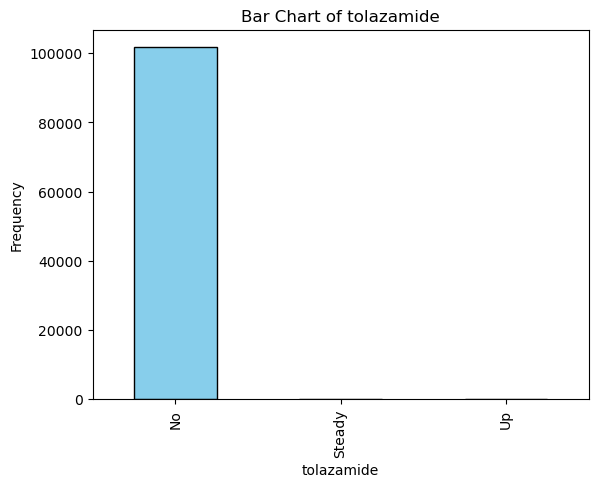

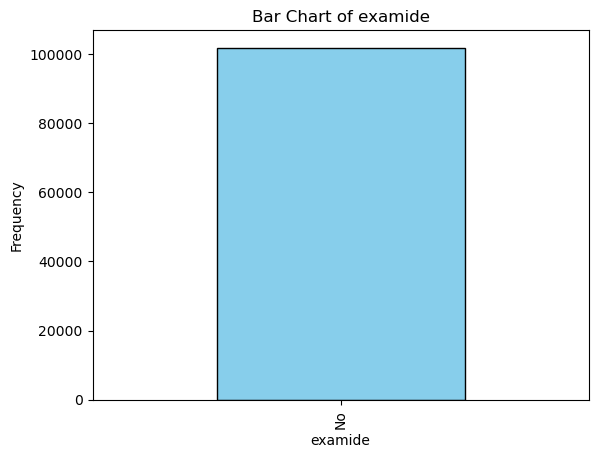

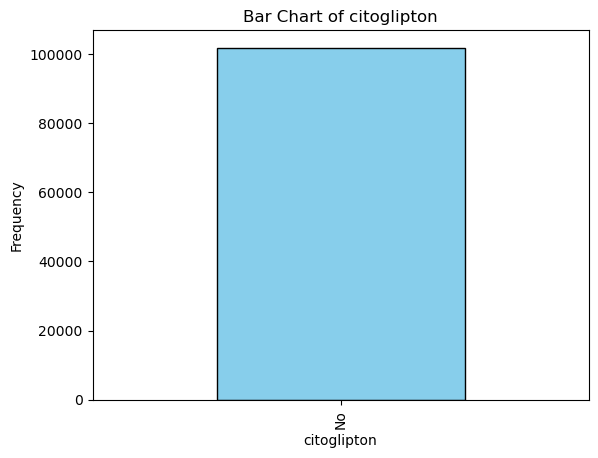

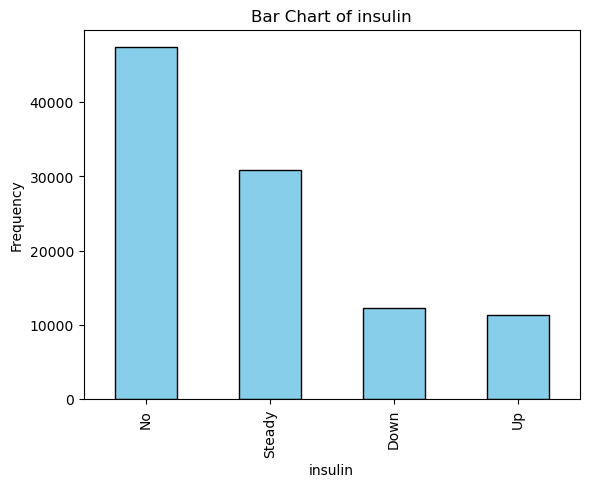

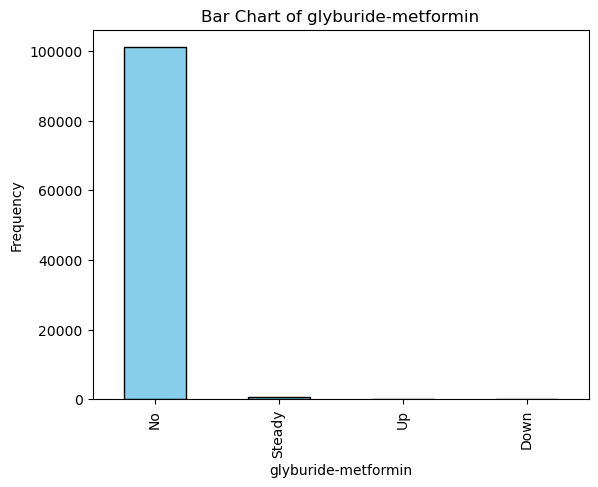

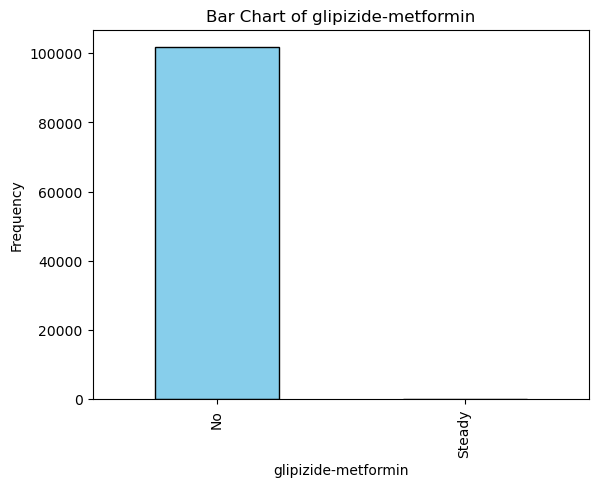

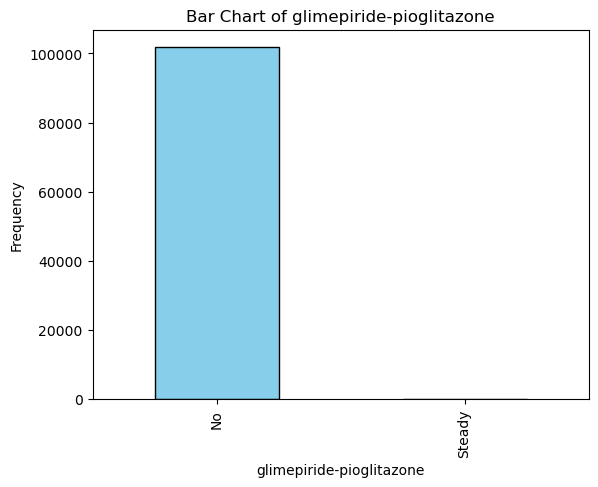

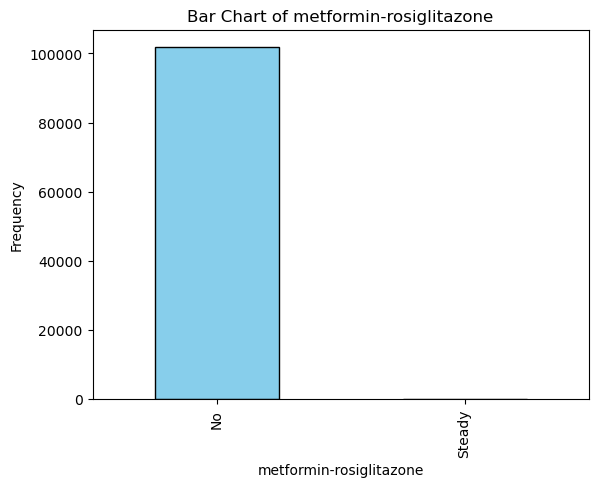

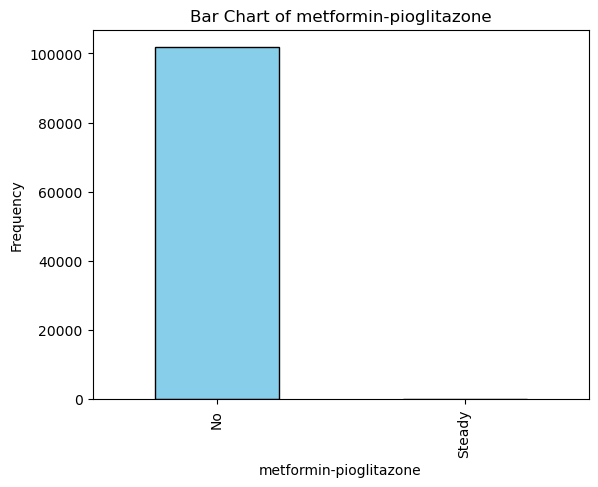

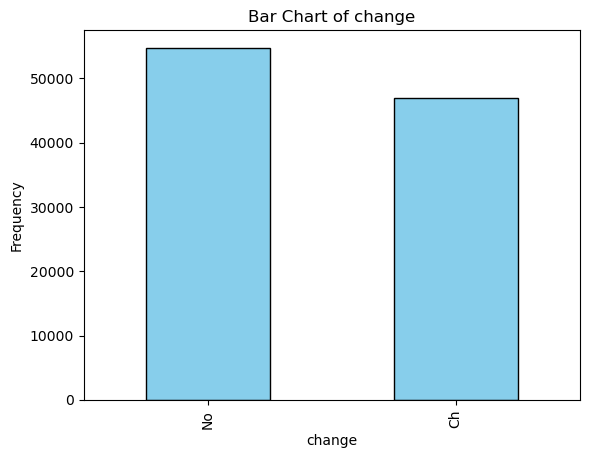

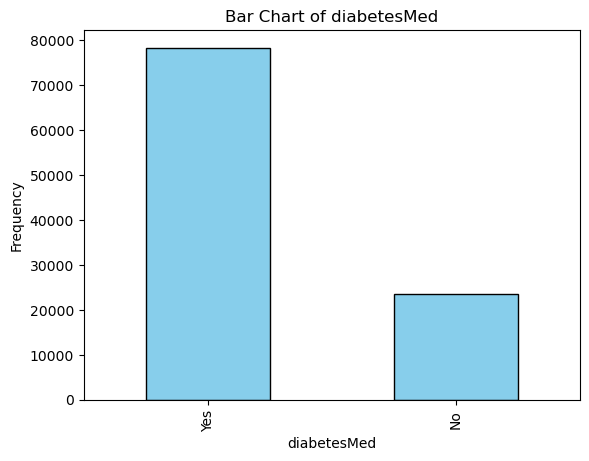

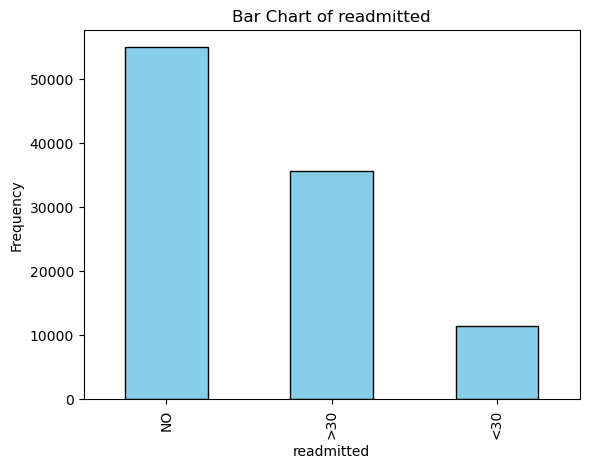

In [13]:
import matplotlib.pyplot as plt

for col in raw_data.select_dtypes(include="object"):
    value_counts = raw_data[col].value_counts()
    
    value_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


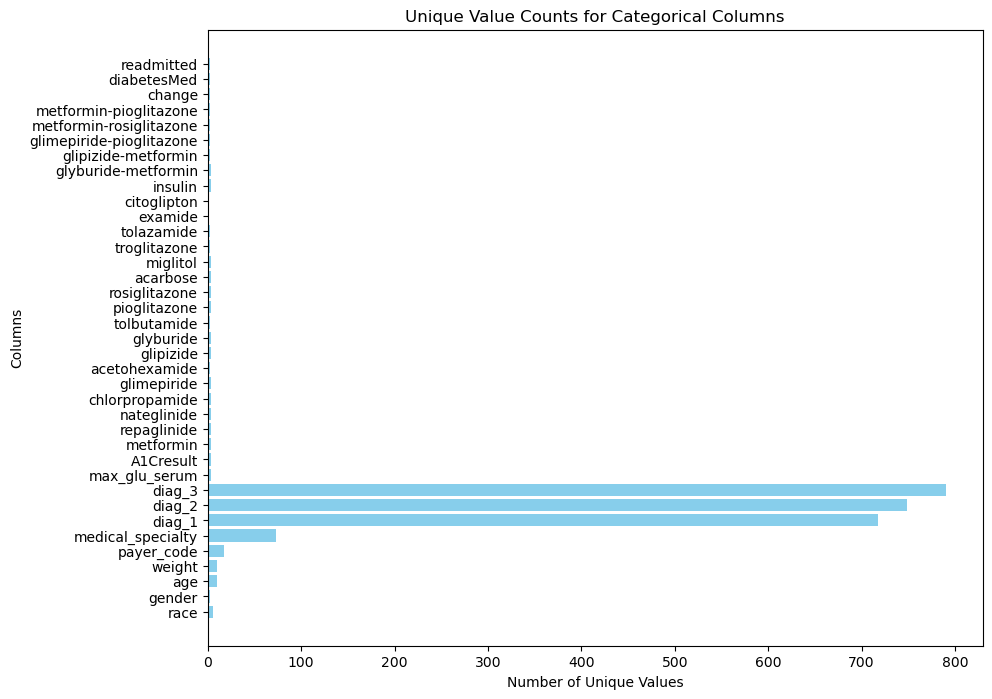

In [30]:
categorical_value_summary = []

for col in raw_data.select_dtypes(include='object'):
    unique_count = len(raw_data[col].unique())
    categorical_value_summary.append({
        'Column': col,
        'Number of Unique Values': unique_count,
    })

categorical_value_summary_df = pd.DataFrame(categorical_value_summary)

plt.figure(figsize=(10, 8))
plt.barh(categorical_value_summary_df['Column'], categorical_value_summary_df['Number of Unique Values'], color='skyblue')
plt.xlabel('Number of Unique Values')
plt.ylabel('Columns')
plt.title('Unique Value Counts for Categorical Columns')
plt.show()

Since we can't get anything useful out of that diagram, let's exclude `diag_1`, `diag_2`, `diag_3`, and `medical_specialty`. 

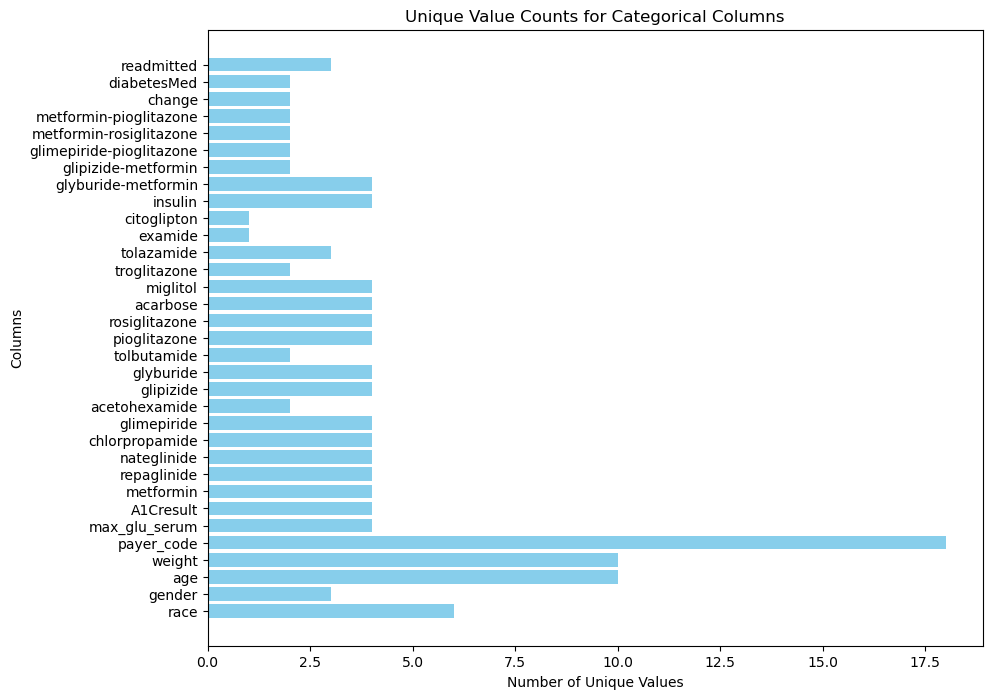

In [31]:
exclude_columns = ['diag_1', 'diag_2', 'diag_3', 'medical_specialty']

categorical_value_summary = []

for col in raw_data.select_dtypes(include='object'):
    if col not in exclude_columns:
        unique_count = len(raw_data[col].unique())
        categorical_value_summary.append({
            'Column': col,
            'Number of Unique Values': unique_count,
        })

categorical_value_summary_df = pd.DataFrame(categorical_value_summary)

plt.figure(figsize=(10, 8))
plt.barh(categorical_value_summary_df['Column'], categorical_value_summary_df['Number of Unique Values'], color='skyblue')
plt.xlabel('Number of Unique Values')
plt.ylabel('Columns')
plt.title('Unique Value Counts for Categorical Columns')
plt.show()

# 5. Multivariate analysis

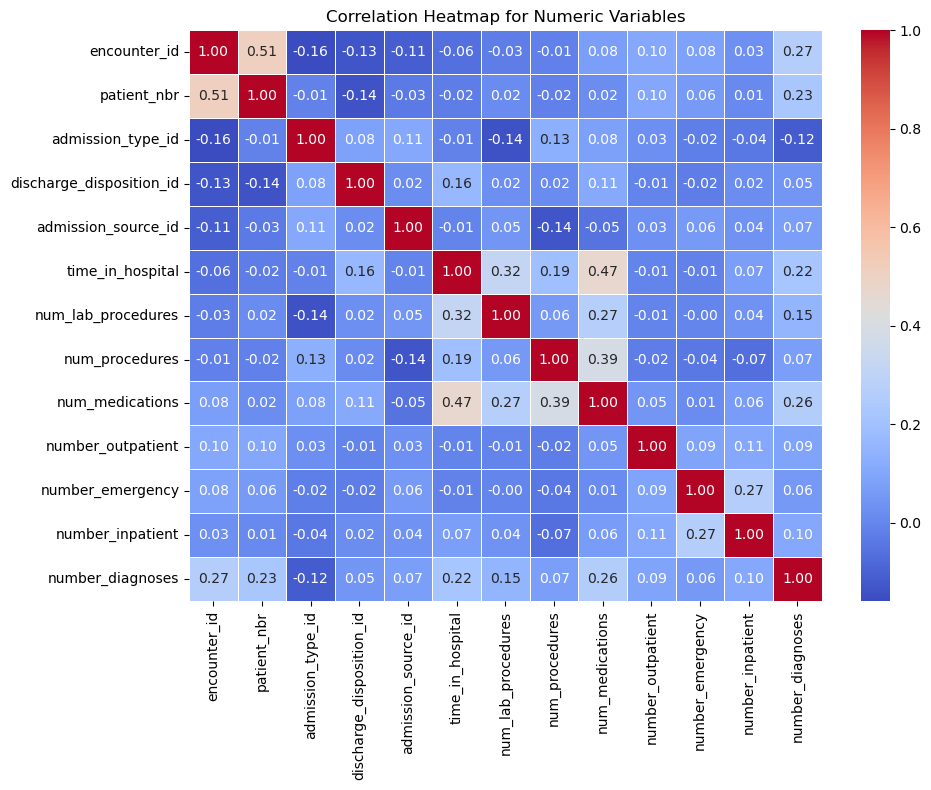

In [28]:
numeric_data = raw_data.select_dtypes(include=['number'])

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout()
plt.show()

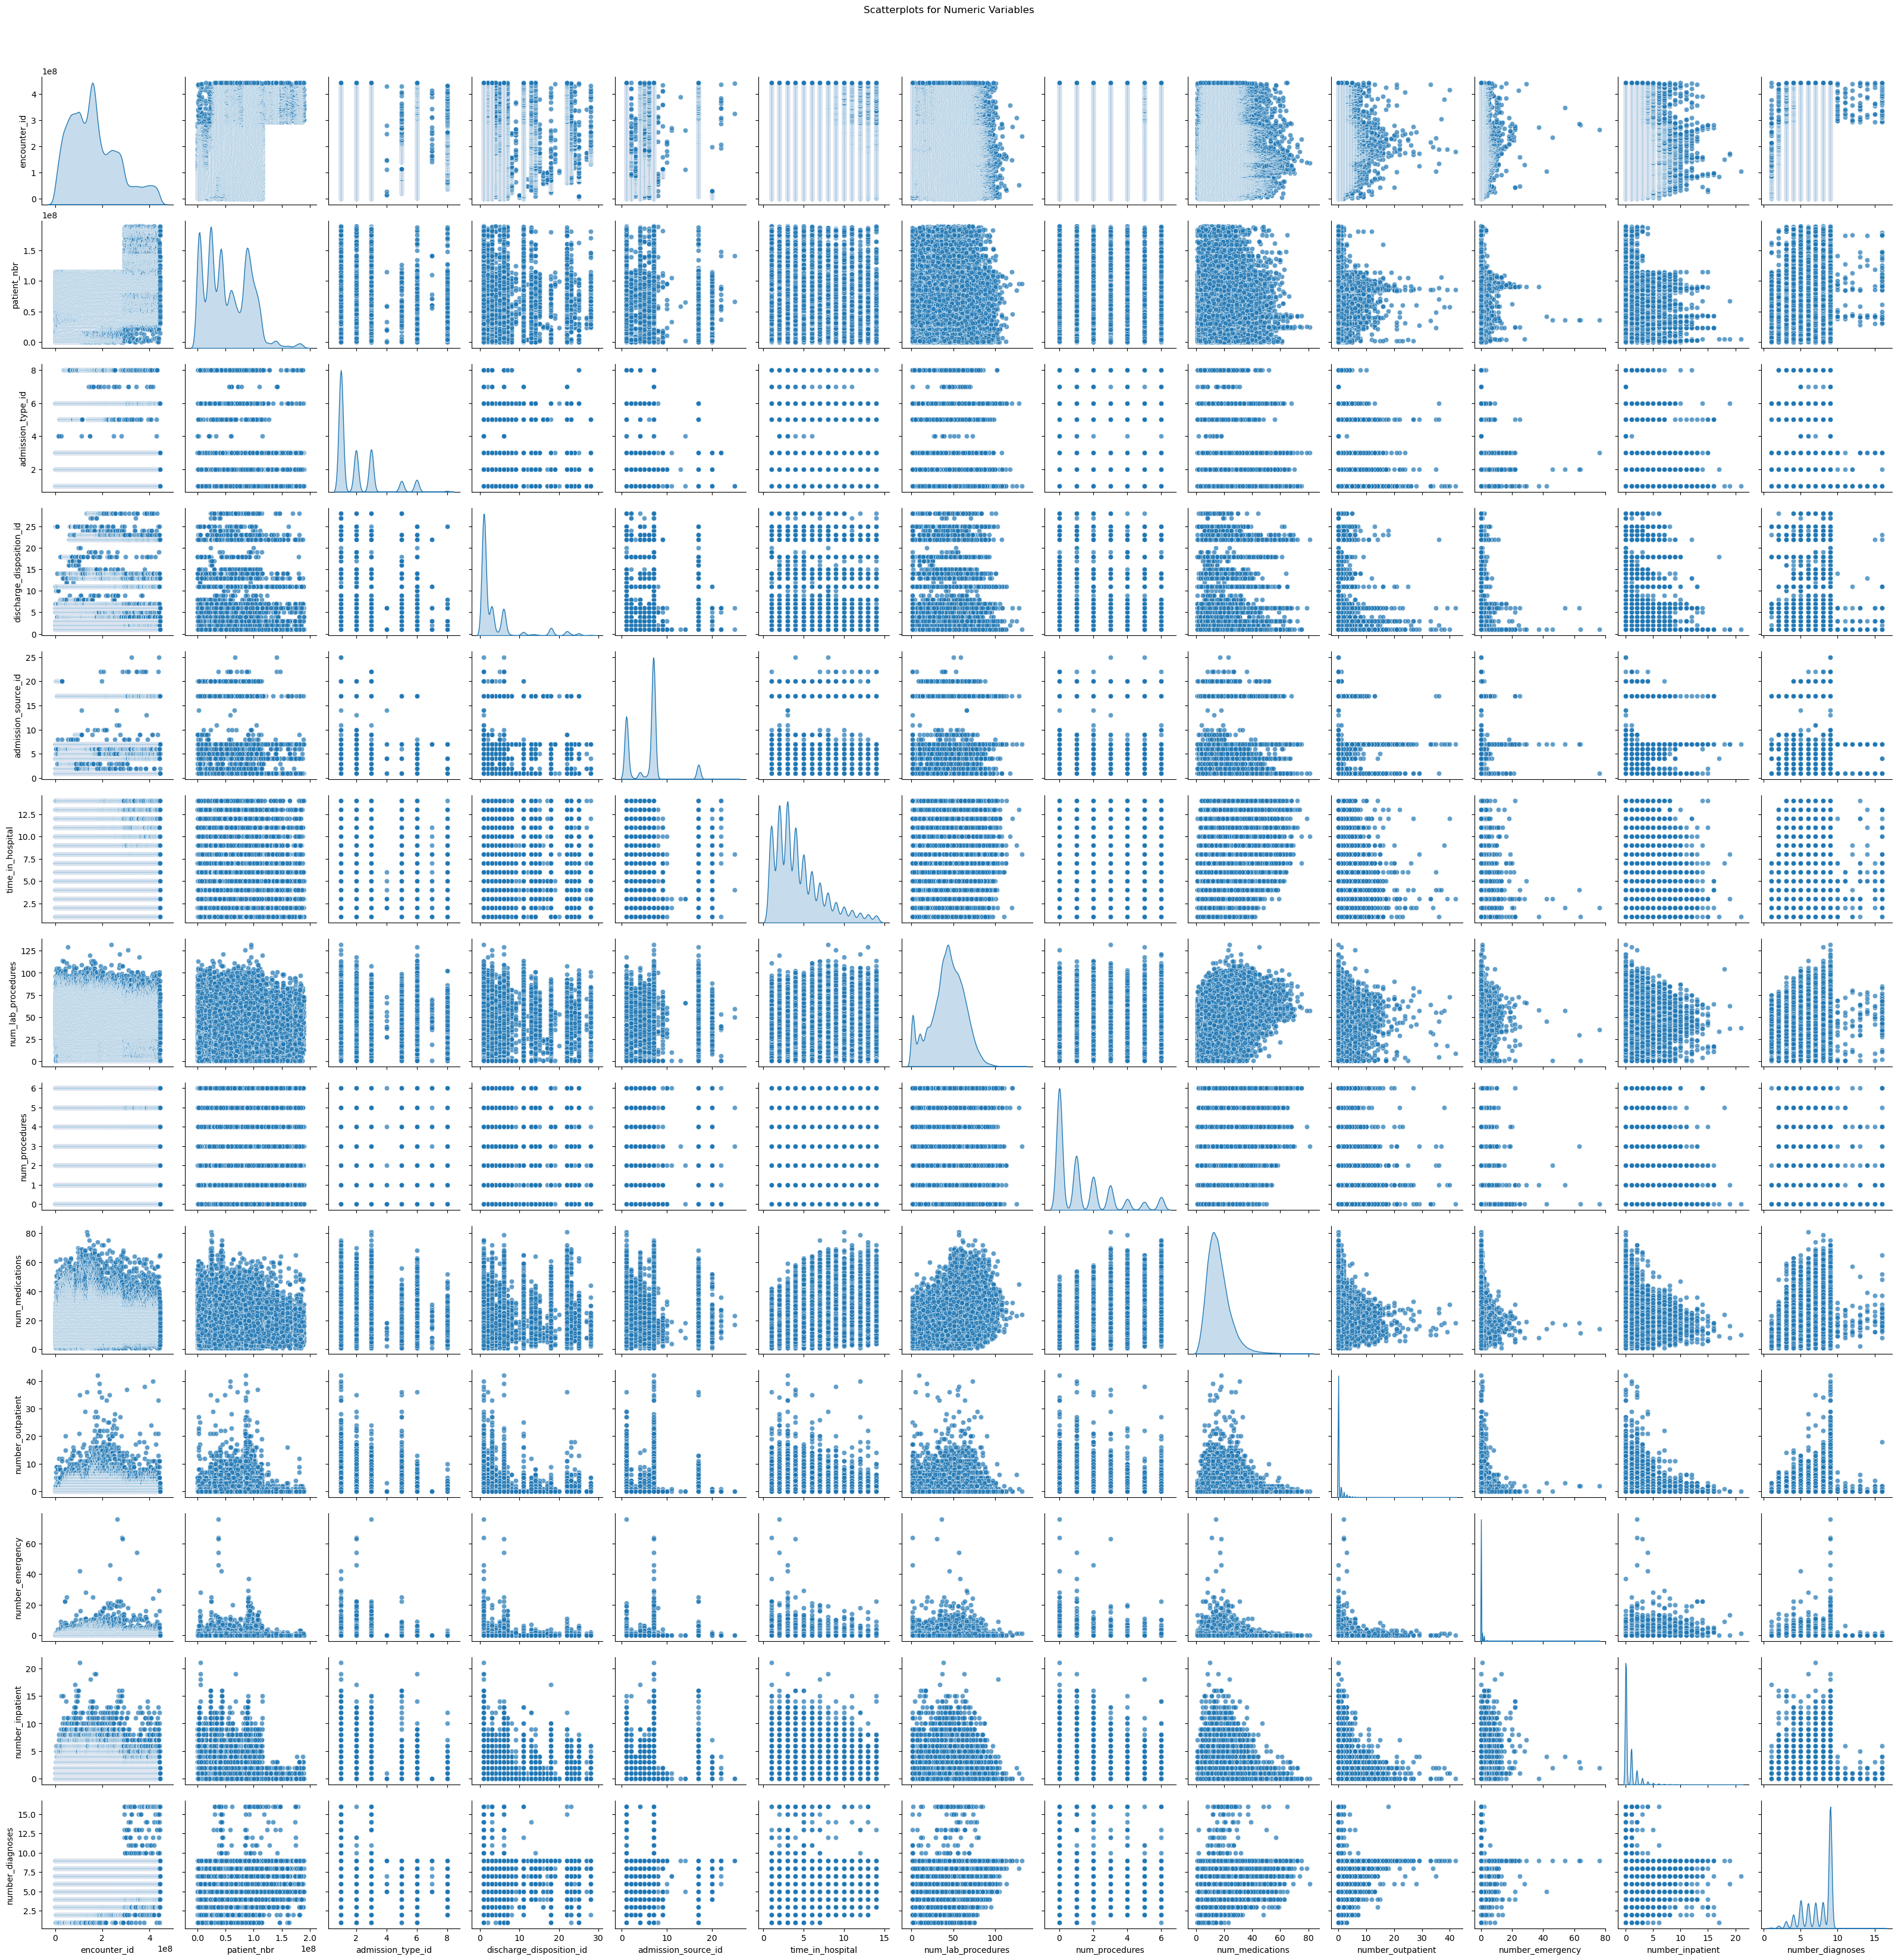

In [40]:
warnings.filterwarnings("ignore", category=FutureWarning)

sns.pairplot(numeric_data_cleaned, diag_kind='kde', plot_kws={'alpha': 0.7})
plt.suptitle('Scatterplots for Numeric Variables', y=1.02)
plt.show()

# 6. Target variable analysis

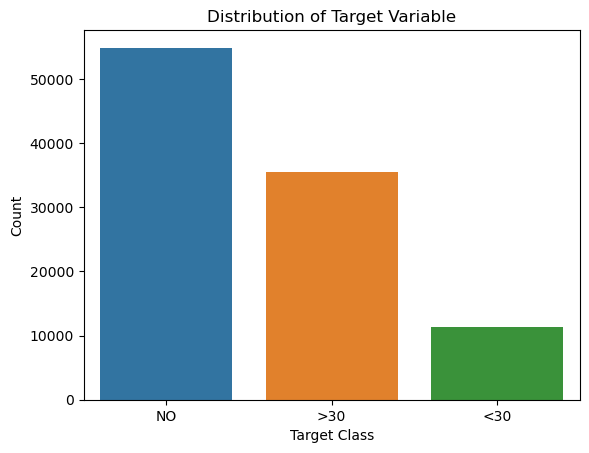

,Class,Count,Percentage
0,NO,54864,53.91
1,>30,35545,34.93
2,<30,11357,11.16


In [5]:
sns.countplot(x='readmitted', data=raw_data)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

target_counts = raw_data['readmitted'].value_counts()
target_percent = raw_data['readmitted'].value_counts(normalize=True) * 100

target_summary_df = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_percent.values.round(2)
})

target_summary_df

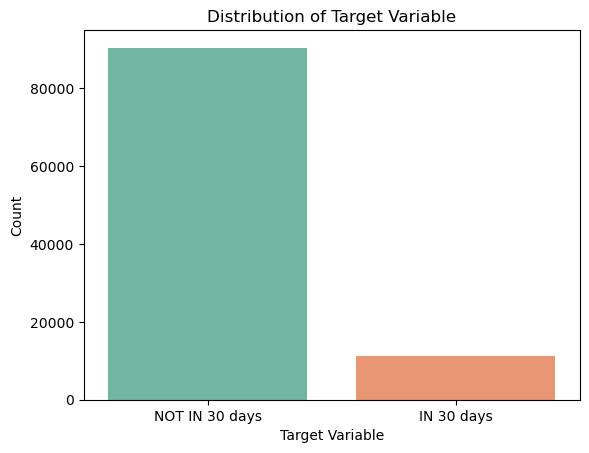

,Class,Count,Percentage
0,NOT IN 30 days,90409,88.84
1,IN 30 days,11357,11.16


In [9]:
readmit_binary = raw_data['readmitted'].replace({
    'NO': 'NOT IN 30 days',
    '>30': 'NOT IN 30 days',
    '<30': 'IN 30 days'
})

sns.countplot(x=readmit_binary, order=['NOT IN 30 days', 'IN 30 days'], palette='Set2')
plt.title('Distribution of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

target_counts = readmit_binary.value_counts()
target_percent = readmit_binary.value_counts(normalize=True) * 100

target_summary_df = pd.DataFrame({
    'Class': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_percent.values.round(2)
}).reset_index(drop=True)

target_summary_df

# 7. Detect and handle outliers

In [23]:
numeric_cols = raw_data.select_dtypes(include=['number']).columns

numeric_cols_df = pd.DataFrame({'Columns': numeric_cols})
numeric_cols_df

,Columns
0,encounter_id
1,patient_nbr
2,admission_type_id
3,discharge_disposition_id
4,admission_source_id
5,time_in_hospital
6,num_lab_procedures
7,num_procedures
8,num_medications
9,number_outpatient


In [29]:
# Manual cause yeah
numeric_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

z_scores = raw_data[numeric_cols].apply(zscore)
outlier_mask = (z_scores.abs() > 3).any(axis=1)
raw_data['is_outlier'] = outlier_mask
outliers_df = raw_data[outlier_mask].copy()

outlier_summary = (z_scores.abs() > 3)
outlier_summary = outlier_summary[outlier_summary.any(axis=1)]

print(f"Number of outlier rows: {outlier_mask.sum()} out of {len(raw_data)}")
print("\nOutlier rows:")
outliers_df.head()

Number of outlier rows: 7193 out of 101766

Outlier rows:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,is_outlier
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,True
66,715086,3376278,Caucasian,Male,[10-20),NaN,1,5,7,1,...,Up,No,No,No,No,No,Ch,Yes,NO,True
73,927786,60679647,Caucasian,Female,[70-80),NaN,3,1,1,14,...,Down,No,No,No,No,No,Ch,Yes,NO,True
114,1810752,6915888,Caucasian,Male,[70-80),NaN,1,3,7,14,...,Up,No,No,No,No,No,Ch,Yes,<30,True
151,2422806,3377124,Caucasian,Male,[40-50),NaN,6,25,1,14,...,No,No,No,No,No,No,Ch,Yes,>30,True


In [30]:
print("\nFeatures causing outliers:")
outlier_summary.head()


Features causing outliers:


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,False,False,False,False,False,False,False,True
66,False,False,False,False,False,False,False,True
73,True,False,False,False,False,False,False,False
114,True,False,False,False,False,False,False,False
151,True,False,False,False,False,False,False,False


In [33]:
percentile_thresholds = [0.01, 0.005, 0.001]

threshold_results = []

total_rows = len(raw_data)

for p in percentile_thresholds:
    lower = raw_data[numeric_cols].quantile(p)
    upper = raw_data[numeric_cols].quantile(1 - p)

    mask = ((raw_data[numeric_cols] < lower) | (raw_data[numeric_cols] > upper)).any(axis=1)
    outlier_count = mask.sum()

    outlier_pct = (outlier_count / total_rows) * 100

    threshold_results.append({
        "Percentile": p,
        "Outlier Rows": outlier_count,
        "Percentage": round(outlier_pct, 2)
    })

results_df = pd.DataFrame(threshold_results)

results_df

,Percentile,Outlier Rows,Percentage
0,0.010,5193,5.10
1,0.005,2764,2.72
2,0.001,540,0.53


About **5,193** rows (**5.1%** of the dataset) had extreme values in one or more numerical features, falling outside the top and bottom **1%** range. These rows will be removed to reduce the impact of outliers.

# 8. Check for data leakage

In [39]:
numeric_cols = raw_data.select_dtypes(include=['number']).copy()

numeric_cols['readmitted_num'] = raw_data['readmitted'].map({'NO': 0, '>30': 0, '<30': 1})

# Now compute correlations with the numeric target
correlations = numeric_cols.corr()['readmitted_num'].sort_values(ascending=False)

correlations_df = correlations.reset_index()
correlations_df.columns = ['Feature', 'Correlation with Readmitted']

correlations_df

,Feature,Correlation with Readmitted
0,readmitted_num,1.000000
1,number_inpatient,0.165147
2,number_emergency,0.060747
3,discharge_disposition_id,0.050560
4,number_diagnoses,0.049524
5,time_in_hospital,0.044199
6,num_medications,0.038432
7,num_lab_procedures,0.020364
8,number_outpatient,0.018893
9,patient_nbr,0.007893


Based on this correlation analysis there doesn't seem to be a feature that has a very strong relationship with the target variable `readmitted`. The highest correlation is only **0.165**, meaning that there are no immediate risk of data leakage. Therefore, all features will be retained.

# 9. Evaluate class imbalance

Since we already saw the class imbalance on our target variable, this section will only discuss about the possible sampling stategies we can take if `SMOTE` (the one we said we'd use in our study) fails.

1. `SMOTE` (currently using)
2. `KMeans-SMOTE`
3. `ADASYN`
4. `SMOTE + ENN`
5. `SMOTE + Tomek Links`

# 10. Feature redundancy and correlation

In [5]:
numeric_cols = raw_data.select_dtypes(include=['number'])

corr_matrix = numeric_cols.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

print("Highly correlated features:", high_corr if high_corr else "NONE")

Highly correlated features: NONE


# 11. Text and categorical checks

In [11]:
category_cols = raw_data.select_dtypes(include='object').columns
category_cols_df = pd.DataFrame({'Columns': category_cols})

category_cols_df

,Columns
0,race
1,gender
2,age
3,weight
4,payer_code
5,medical_specialty
6,diag_1
7,diag_2
8,diag_3
9,max_glu_serum


In [14]:
threshold = 0.01 * len(raw_data)

summary_data = []

for col in category_cols:
    value_counts = raw_data[col].value_counts(dropna=False)
    rare_cats = value_counts[value_counts < threshold].index.tolist()
    
    summary_data.append({
        "Column": col,
        "Unique Categories": value_counts.shape[0],
        "Sample Categories": list(value_counts.index[:5]),
        "Rare Categories (<1%)": rare_cats[:5] if rare_cats else "NONE"
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Column,Unique Categories,Sample Categories,Rare Categories (<1%)
0,race,6,"[Caucasian, AfricanAmerican, nan, Hispanic, Ot...",[Asian]
1,gender,3,"[Female, Male, Unknown/Invalid]",[Unknown/Invalid]
2,age,10,"[[70-80), [60-70), [50-60), [80-90), [40-50)]","[[10-20), [0-10)]"
3,weight,10,"[nan, [75-100), [50-75), [100-125), [125-150)]","[[50-75), [100-125), [125-150), [25-50), [0-25)]"
4,payer_code,18,"[nan, MC, HM, SP, BC]","[PO, DM, CH, WC, OT]"
5,medical_specialty,73,"[nan, InternalMedicine, Emergency/Trauma, Fami...","[Pulmonology, Psychiatry, Urology, Obstetricsa..."
6,diag_1,717,"[428, 414, 786, 410, 486]","[435, 562, 574, 296, 560]"
7,diag_2,749,"[276, 428, 250, 427, 401]","[250.6, 493, 305, 786, 280]"
8,diag_3,790,"[250, 401, 276, 428, 427]","[584, 305, 250.01, 682, 518]"
9,max_glu_serum,4,"[None, Norm, >200, >300]",NONE


# Conclusion

# TODO
1. Drop columns with high missing values
2. Drop outliers